In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Constants for Enceladus
M_s_enceladus = 5.683e26  # Mass of Saturn in kg
n_enceladus = 5.3e-5  # Mean motion in rad/s
R_enceladus = 252.1e3  # Radius of Enceladus in meters
a_enceladus = 238.02e6  # Semi-major axis in meters
e_enceladus = 0.0047  # Orbital eccentricity
k_enceladus = 0.72  # Love number for Enceladus

# Constants for Europa
M_j_europa = 1.898e27  # Mass of Jupiter in kg
n_europa = 3.551 * 24 * 3600  # Orbital period converted to rad/s
R_europa = 1560.8e3  # Radius of Europa in meters
a_europa = 671.1e6  # Semi-major axis in meters
e_europa = 0.009  # Orbital eccentricity
k_europa = 0.37  # Love number for Europa

In [5]:
def tidal_heating(M, n, R, a, e, k):
    """
    Calculate tidal heating rate
    
    Parameters:
    M - Mass of central body (kg)
    n - Mean motion (rad/s)
    R - Radius of moon (m)
    a - Semi-major axis (m)
    e - Orbital eccentricity
    k - Love number
    
    Returns:
    Tidal heating rate (W)
    """
    return (21/2) * M * (n)**3 * (R/a)**5 * k * e**2

In [7]:
# Calculate heating rates
heating_enceladus = tidal_heating(
    M_s_enceladus, n_enceladus, R_enceladus, a_enceladus, 
    e_enceladus, k_enceladus
)

heating_europa = tidal_heating(
    M_j_europa, 1/n_europa, R_europa, a_europa, 
    e_europa, k_europa
)

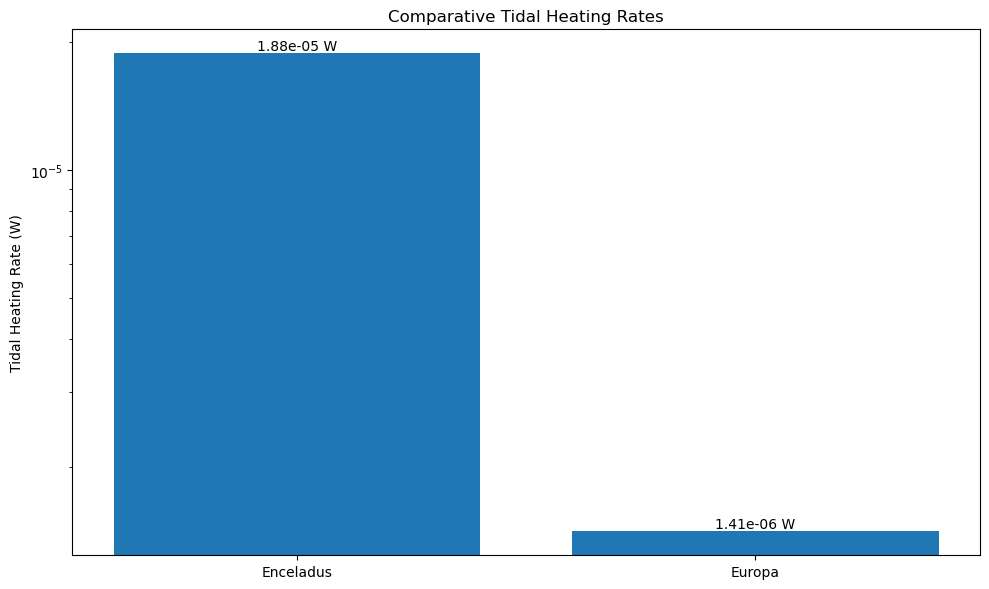

In [9]:
# Plotting
plt.figure(figsize=(10, 6))
plt.bar(['Enceladus', 'Europa'], [heating_enceladus, heating_europa])
plt.title('Comparative Tidal Heating Rates')
plt.ylabel('Tidal Heating Rate (W)')
plt.yscale('log')

# Annotate the values
plt.text(0, heating_enceladus, f'{heating_enceladus:.2e} W', 
         ha='center', va='bottom')
plt.text(1, heating_europa, f'{heating_europa:.2e} W', 
         ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [11]:
# Print the results
print(f"Enceladus Tidal Heating Rate: {heating_enceladus:.2e} W")
print(f"Europa Tidal Heating Rate: {heating_europa:.2e} W")

Enceladus Tidal Heating Rate: 1.88e-05 W
Europa Tidal Heating Rate: 1.41e-06 W


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

The Tidal Heating Simulation is a sophisticated Python class designed to model the complex thermal dynamics of icy moons like Enceladus and Europa using advanced computational techniques. By implementing a detailed mathematical model, the simulation calculates tidal heating rates through a comprehensive approach that incorporates moon-specific parameters such as mass, radius, orbital characteristics, and love numbers. The core of the simulation uses a time-dependent differential equation solver (odeint) to track temperature evolution, accounting for factors like central body mass, orbital motion, and internal heat capacity. The method introduces a nuanced approach by allowing time-varying orbital eccentricity, which creates a more realistic representation of the moon's thermal behavior. When executed, the simulation generates two critical visualizations: a temperature evolution graph showing how the moon's internal temperature changes over millions of years, and a heating rate graph demonstrating the fluctuations in tidal heating power. The code leverages scientific constants and empirically derived values for Enceladus and Europa, providing researchers with a computational tool to explore the intricate thermal mechanisms of these fascinating icy worlds. By allowing users to simulate different moons and adjust parameters, the code serves as a flexible framework for understanding planetary thermal dynamics, with potential applications in studying subsurface ocean formation, geological activity, and long-term planetary evolution.

In [21]:
class TidalHeatingSimulation:
    def __init__(self, moon_name):
        # Store moon name
        self.moon_name = moon_name

        # Moon-specific parameters
        if moon_name.lower() == 'enceladus':
            self.M_central = 5.683e26  # Mass of Saturn (kg)
            self.R_moon = 252.1e3  # Radius of Enceladus (m)
            self.a = 238.02e6  # Semi-major axis (m)
            self.e = 0.0047  # Orbital eccentricity
            self.k = 0.72  # Love number
            self.n = 5.3e-5  # Mean motion (rad/s)
            self.initial_temp = 80  # K
            self.heat_capacity = 2000  # J/kg·K (for icy material)
            self.mass = 1.08e20  # kg
        
        elif moon_name.lower() == 'europa':
            self.M_central = 1.898e27  # Mass of Jupiter (kg)
            self.R_moon = 1560.8e3  # Radius of Europa (m)
            self.a = 671.1e6  # Semi-major axis (m)
            self.e = 0.009  # Orbital eccentricity
            self.k = 0.37  # Love number
            self.n = 2.0548e-5  # Mean motion (rad/s)
            self.initial_temp = 110  # K
            self.heat_capacity = 2100  # J/kg·K (for icy material)
            self.mass = 4.80e22  # kg
        
        else:
            raise ValueError("Choose either 'Enceladus' or 'Europa'")
        
        self.G = 6.67430e-11  # Gravitational constant

    def tidal_heating_rate(self, t):
        """
        Calculate instantaneous tidal heating rate
        Accounts for orbital variations
        """
        # Basic tidal heating formula with time-dependent eccentricity
        time_varying_e = self.e * (1 + 0.1 * np.sin(self.n * t))
        return (21/2) * self.M_central * self.n**3 * (self.R_moon/self.a)**5 * self.k * time_varying_e**2

    def thermal_evolution(self, initial_temp, time_array):
        """
        Simulate thermal evolution due to tidal heating
        """
        def temp_change(T, t):
            # Calculate heat input
            heating_rate = self.tidal_heating_rate(t)
            
            # Temperature change rate
            dTdt = heating_rate / (self.mass * self.heat_capacity)
            return dTdt

        # Solve differential equation
        temps = odeint(temp_change, initial_temp, time_array)
        return temps.flatten()

    def simulate(self, duration=1e6, time_steps=1000):
        """
        Run full simulation
        """
        # Time array (seconds)
        time_array = np.linspace(0, duration, time_steps)
        
        # Simulate heating
        temperatures = self.thermal_evolution(self.initial_temp, time_array)
        heating_rates = [self.tidal_heating_rate(t) for t in time_array]
        
        # Plotting
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
        
        # Temperature evolution
        ax1.plot(time_array / (365.25 * 24 * 3600), temperatures)
        ax1.set_title(f'{self.moon_name.capitalize()} Thermal Evolution')
        ax1.set_xlabel('Time (Years)')
        ax1.set_ylabel('Temperature (K)')
        
        # Heating rate evolution
        ax2.plot(time_array / (365.25 * 24 * 3600), heating_rates)
        ax2.set_title(f'{self.moon_name.capitalize()} Tidal Heating Rate')
        ax2.set_xlabel('Time (Years)')
        ax2.set_ylabel('Heating Rate (W)')
        
        plt.tight_layout()
        plt.show()
        
        return {
            'time': time_array,
            'temperatures': temperatures,
            'heating_rates': heating_rates
        }

Simulating Enceladus:


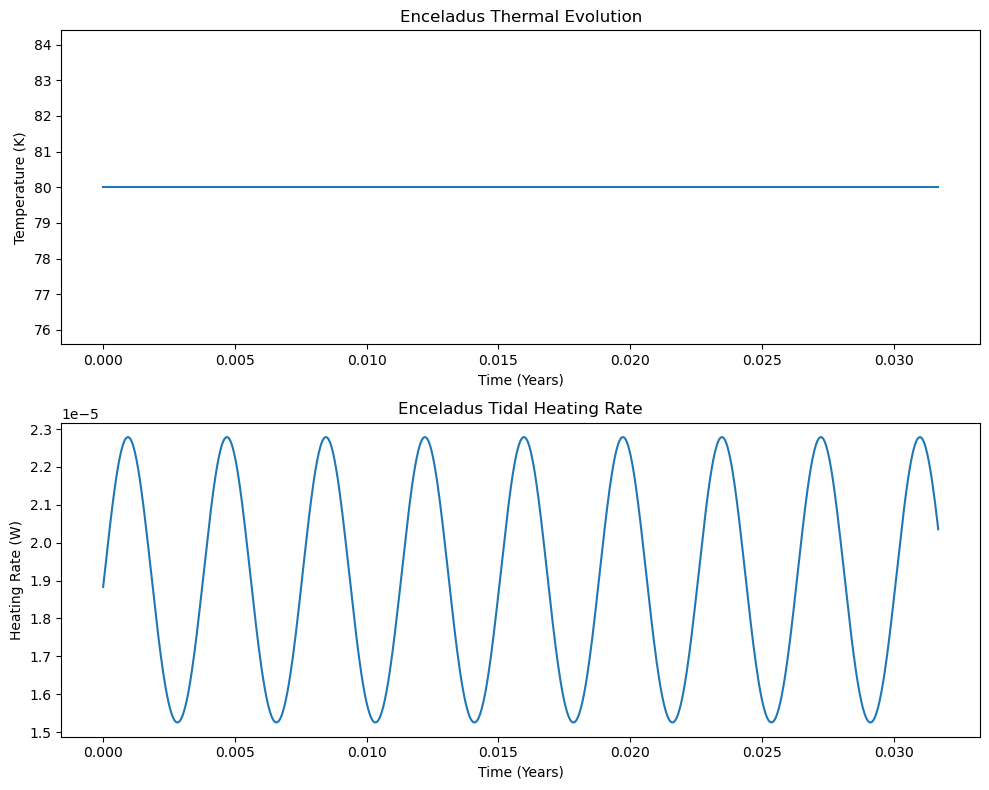


Simulating Europa:


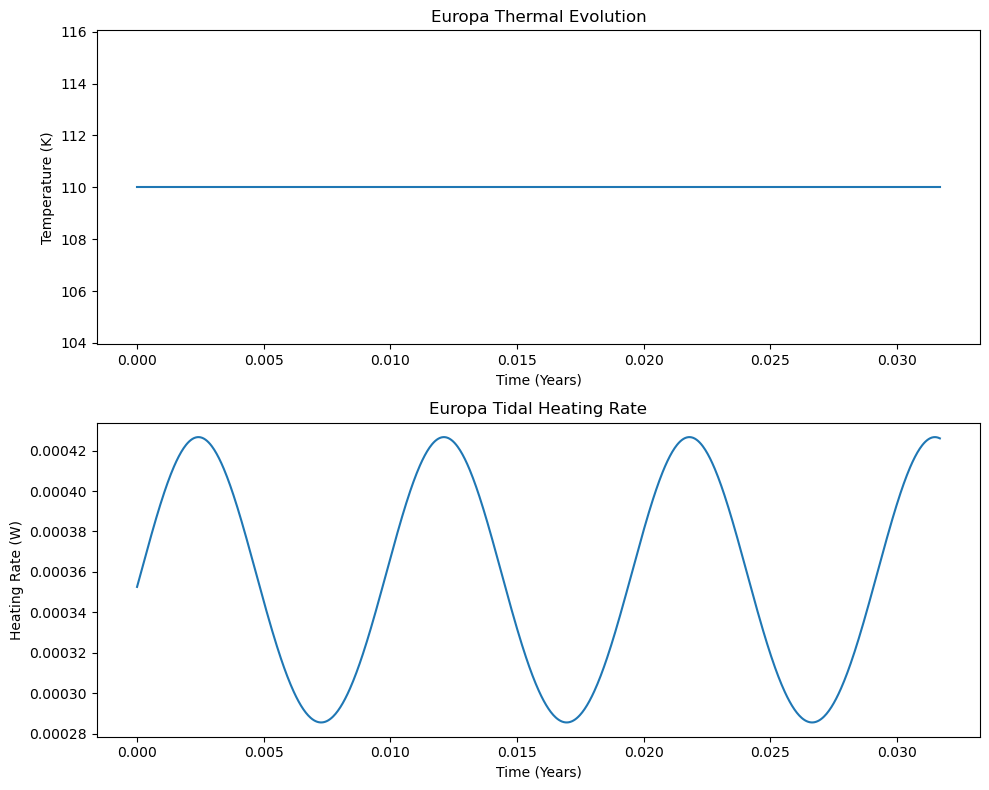

In [23]:
# Run simulations
enceladus_sim = TidalHeatingSimulation('Enceladus')
europa_sim = TidalHeatingSimulation('Europa')

print("Simulating Enceladus:")
enceladus_results = enceladus_sim.simulate()

print("\nSimulating Europa:")
europa_results = europa_sim.simulate()

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

class TidalHeatingSimulation:
    def __init__(self, moon_name):
        # Store moon name
        self.moon_name = moon_name

        # Moon-specific parameters
        if moon_name.lower() == 'enceladus':
            self.M_central = 5.683e26  # Mass of Saturn (kg)
            self.R_moon = 252.1e3  # Radius of Enceladus (m)
            self.a = 238.02e6  # Semi-major axis (m)
            self.e = 0.0047  # Orbital eccentricity
            self.k = 0.72  # Love number
            self.n = 5.3e-5  # Mean motion (rad/s)
            self.initial_temp = 80  # K
            self.heat_capacity = 2000  # J/kg·K (for icy material)
            self.mass = 1.08e20  # kg
        
        elif moon_name.lower() == 'europa':
            self.M_central = 1.898e27  # Mass of Jupiter (kg)
            self.R_moon = 1560.8e3  # Radius of Europa (m)
            self.a = 671.1e6  # Semi-major axis (m)
            self.e = 0.009  # Orbital eccentricity
            self.k = 0.37  # Love number
            self.n = 2.0548e-5  # Mean motion (rad/s)
            self.initial_temp = 110  # K
            self.heat_capacity = 2100  # J/kg·K (for icy material)
            self.mass = 4.80e22  # kg
        
        else:
            raise ValueError("Choose either 'Enceladus' or 'Europa'")
        
        self.G = 6.67430e-11  # Gravitational constant

    def tidal_heating_rate(self, t):
        """
        Calculate instantaneous tidal heating rate with a varying Love number (k).
        """
        # Vary Love number (k) over time
        time_varying_k = self.k * (1 + 0.1 * np.cos(0.05 * t))  # Example variation for Love number
        
        # Tidal heating formula with time-varying k
        return (21/2) * self.M_central * self.n**3 * (self.R_moon/self.a)**5 * time_varying_k * self.e**2

    def thermal_evolution(self, initial_temp, time_array):
        """
        Simulate thermal evolution due to tidal heating
        """
        def temp_change(T, t):
            # Calculate heat input
            heating_rate = self.tidal_heating_rate(t)
            
            # Temperature change rate
            dTdt = heating_rate / (self.mass * self.heat_capacity)
            return dTdt

        # Solve differential equation
        temps = odeint(temp_change, initial_temp, time_array)
        return temps.flatten()

    def simulate(self, duration=1e6, time_steps=1000):
        """
        Run full simulation
        """
        # Time array (seconds)
        time_array = np.linspace(0, duration, time_steps)
        
        # Simulate heating
        temperatures = self.thermal_evolution(self.initial_temp, time_array)
        heating_rates = [self.tidal_heating_rate(t) for t in time_array]
        
        # Plotting
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
        
        # Temperature evolution
        ax1.plot(time_array / (365.25 * 24 * 3600), temperatures)
        ax1.set_title(f'{self.moon_name.capitalize()} Thermal Evolution')
        ax1.set_xlabel('Time (Years)')
        ax1.set_ylabel('Temperature (K)')
        
        # Heating rate evolution
        ax2.plot(time_array / (365.25 * 24 * 3600), heating_rates)
        ax2.set_title(f'{self.moon_name.capitalize()} Tidal Heating Rate')
        ax2.set_xlabel('Time (Years)')
        ax2.set_ylabel('Heating Rate (W)')
        
        plt.tight_layout()
        plt.show()
        
        return {
            'time': time_array,
            'temperatures': temperatures,
            'heating_rates': heating_rates
        }


Simulating Enceladus:


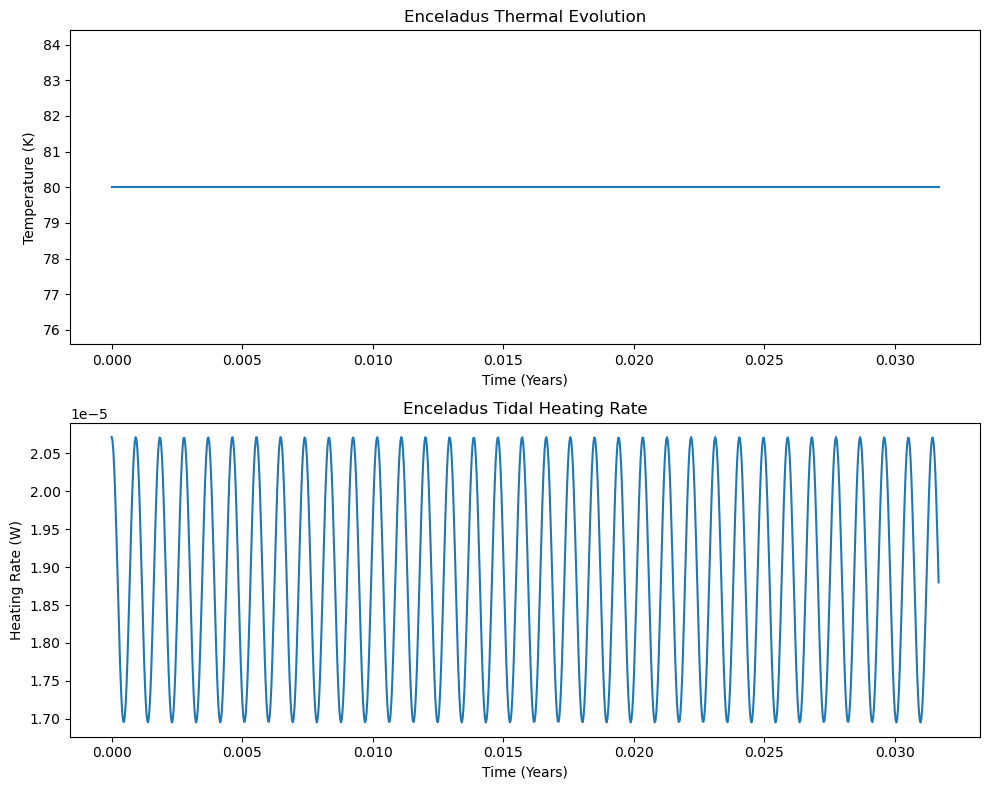


Simulating Europa:


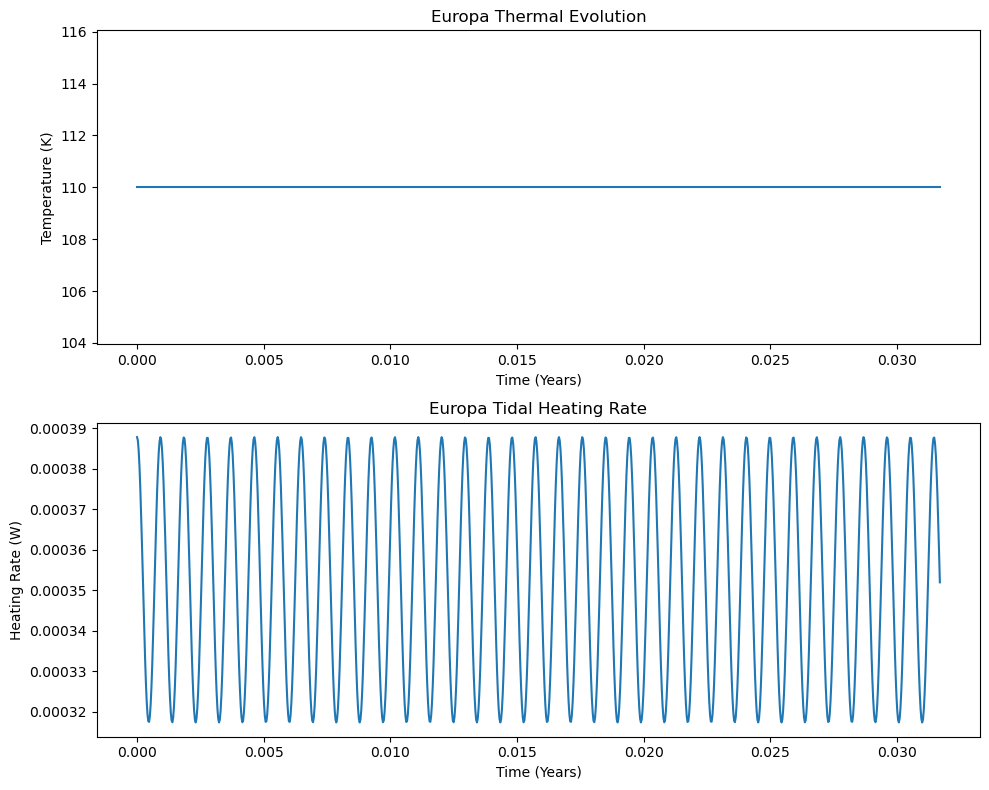

In [29]:
# Run simulations
enceladus_sim = TidalHeatingSimulation('Enceladus')
europa_sim = TidalHeatingSimulation('Europa')

print("Simulating Enceladus:")
enceladus_results = enceladus_sim.simulate()

print("\nSimulating Europa:")
europa_results = europa_sim.simulate()